In [34]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [35]:
file = uproot.open("build/yz.root")

print(file.keys()) 
tree = file["yz"]
df = tree.arrays(library="pd")

['yz;1']


### STEP 1
Plottare tutte e quantità del file

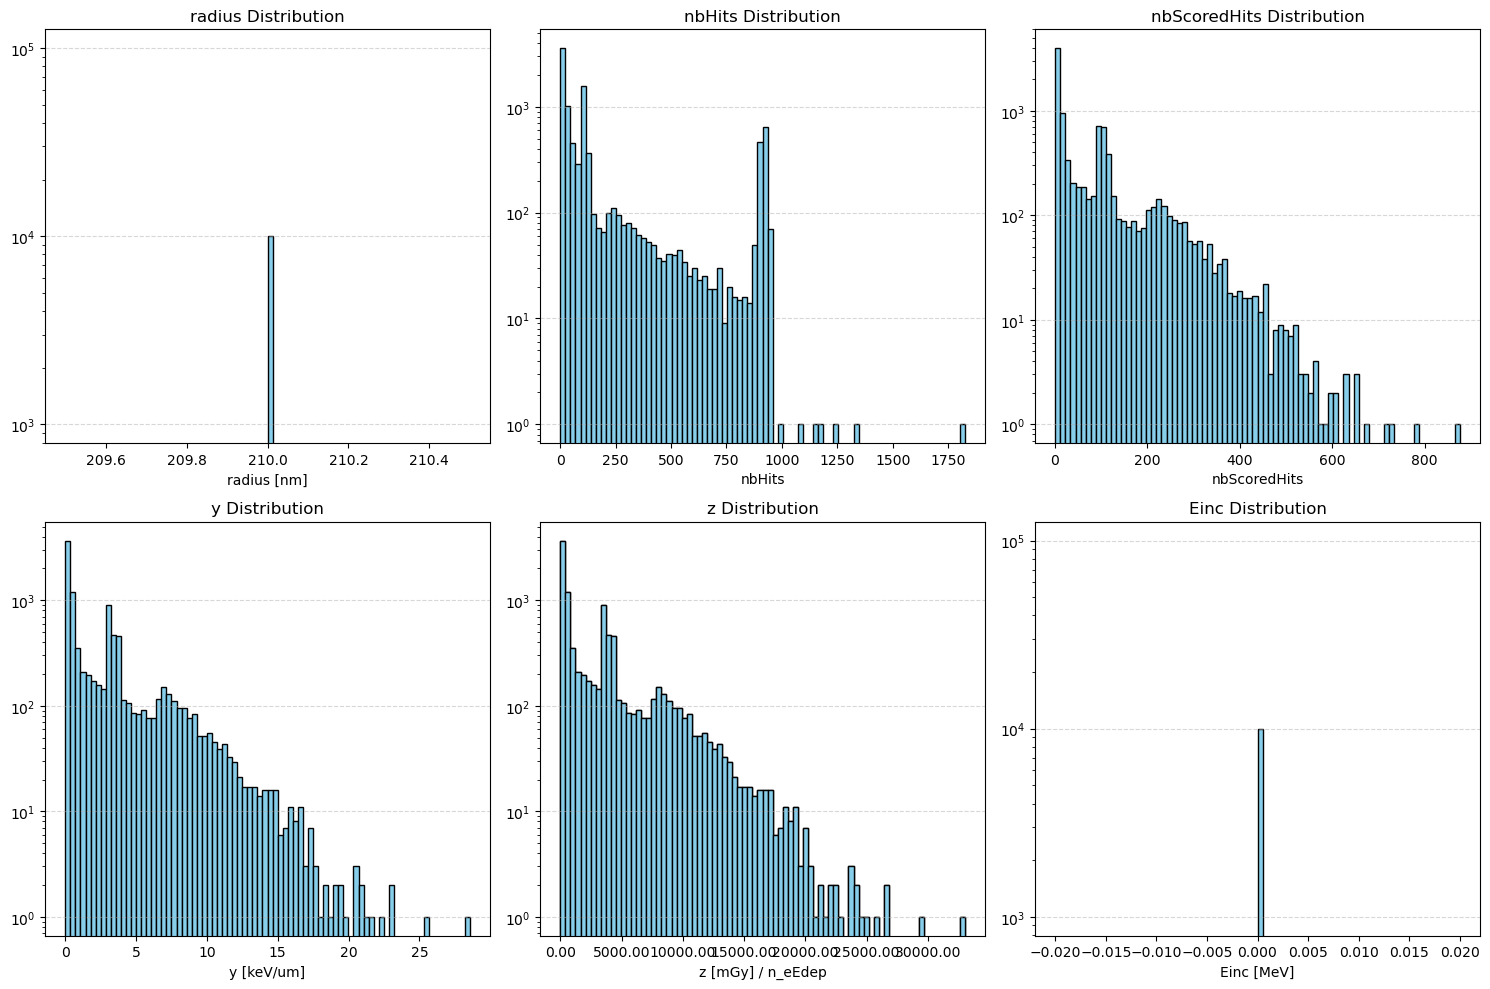

In [36]:
custom_ranges = {
    'radius': None,
    'nbHits': None,
    'nbScoredHits': None,
    'y': None,
    'z': None,
    'Einc': (-0.02, 0.02)
}

cols_to_plot = ['radius', 'nbHits', 'nbScoredHits', 'y', 'z', 'Einc']

units = {
    'radius': ' [nm]',
    'nbHits': '',
    'nbScoredHits': '',
    'y': ' [keV/um]',
    'z': ' [Gy]',
    'Einc': ' [MeV]'
} # Controlla se sto facendo bene...!
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    is_log = col in ['y', 'z', 'Einc']
    
    # range personalizzato
    axes[i].hist(df[col], bins=80, range=custom_ranges.get(col), 
                 color='skyblue', edgecolor='black', log=is_log)
    
    axes[i].set_yscale('log')
    axes[i].set_title(f'{col} Distribution')
    
    # Per z moltiplichiamo l'asse x per 1000 per ottenere tutto in mGy
    if col == 'z':
        axes[i].hist(df[col], bins=80, range=custom_ranges.get(col), 
                 color='skyblue', edgecolor='black', log=is_log)
        axes[i].set_xlabel(f"{col} [mGy] / n_eEdep")
        # In notazione scientifica con 2 decimali
        axes[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*1e3:.2f}'))
    else:
        axes[i].set_xlabel(f"{col}{units.get(col, '')}")
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

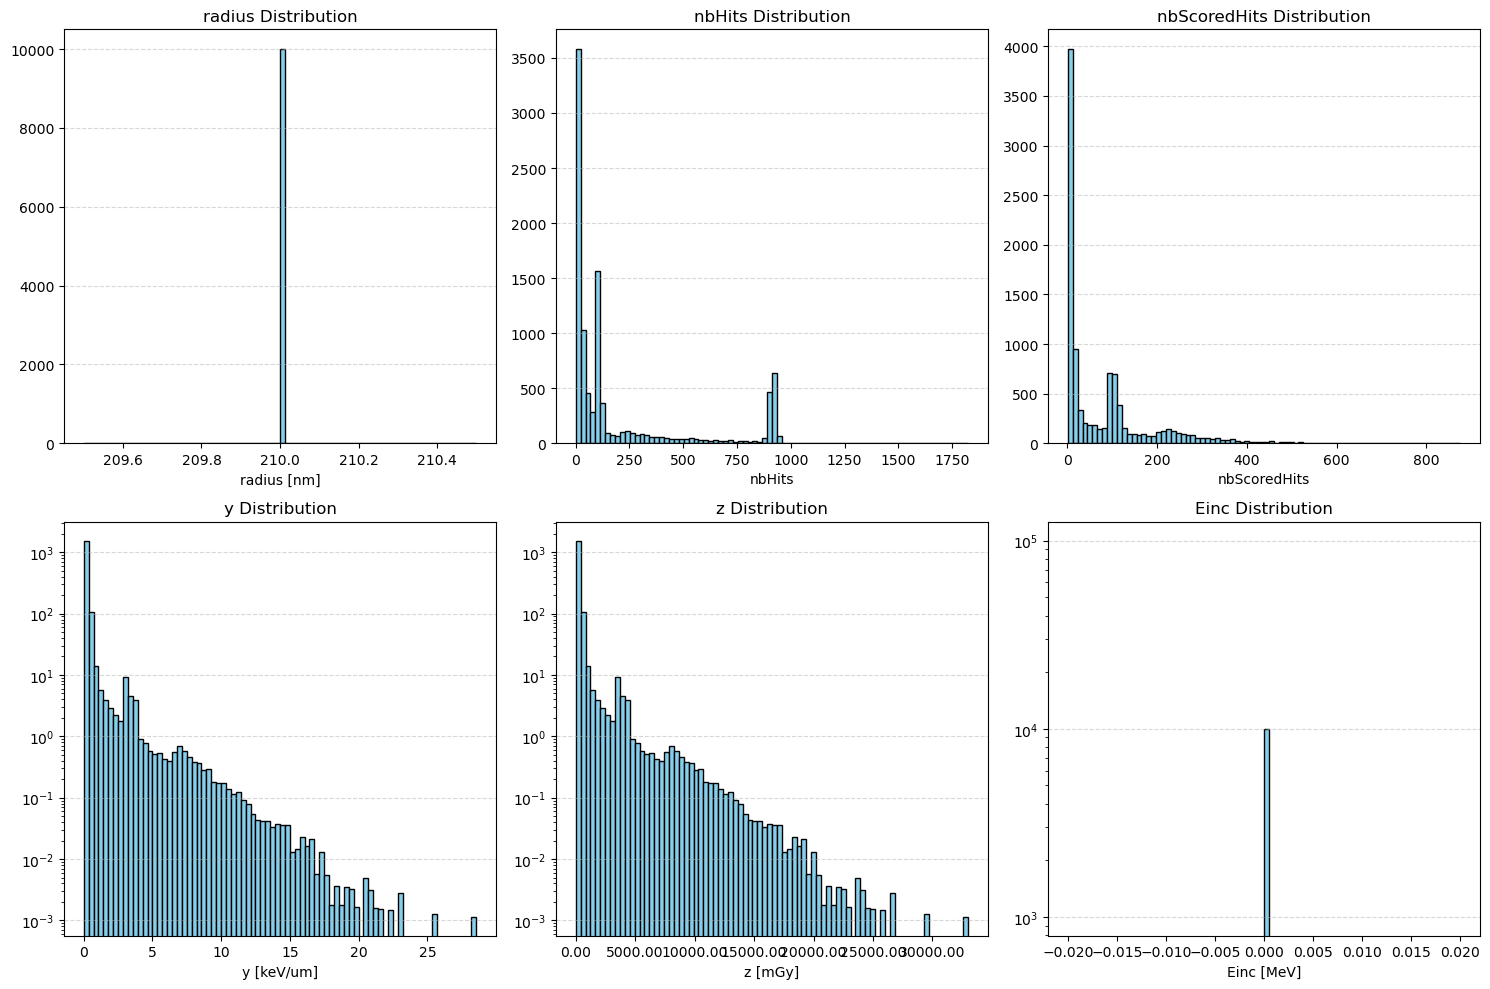

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Pulizia e Calcolo Pesi (fatto UNA volta sola, prima del plot)
# Se nbScoredHits è > 0, pesiamo, altrimenti 0
df['weight'] = np.where(df['nbScoredHits'] > 0, 1.0 / df['nbScoredHits'], 0.0)

# 2. Configurazione Plot
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    # Logica per i pesi: usiamo i pesi solo per y e z, altrimenti None (nessun peso)
    current_weights = df['weight'] if col in ['y', 'z'] else None
    
    # Decidiamo se il plot deve essere logaritmico
    is_log = col in ['y', 'z', 'Einc']
    
    # 3. UNICO comando hist (molto più pulito)
    axes[i].hist(df[col], bins=80, range=custom_ranges.get(col), 
                 color='skyblue', edgecolor='black', log=is_log, 
                 weights=current_weights)
    
    axes[i].set_title(f'{col} Distribution')
    
    # 4. Formattazione Etichette dinamica
    if col == 'z':
        axes[i].set_xlabel(f"{col} [mGy]")
        axes[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*1e3:.2f}'))
    elif col == 'y':
        axes[i].set_xlabel(f"{col} [keV/um]")
    else:
        axes[i].set_xlabel(f"{col}{units.get(col, '')}")
        
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

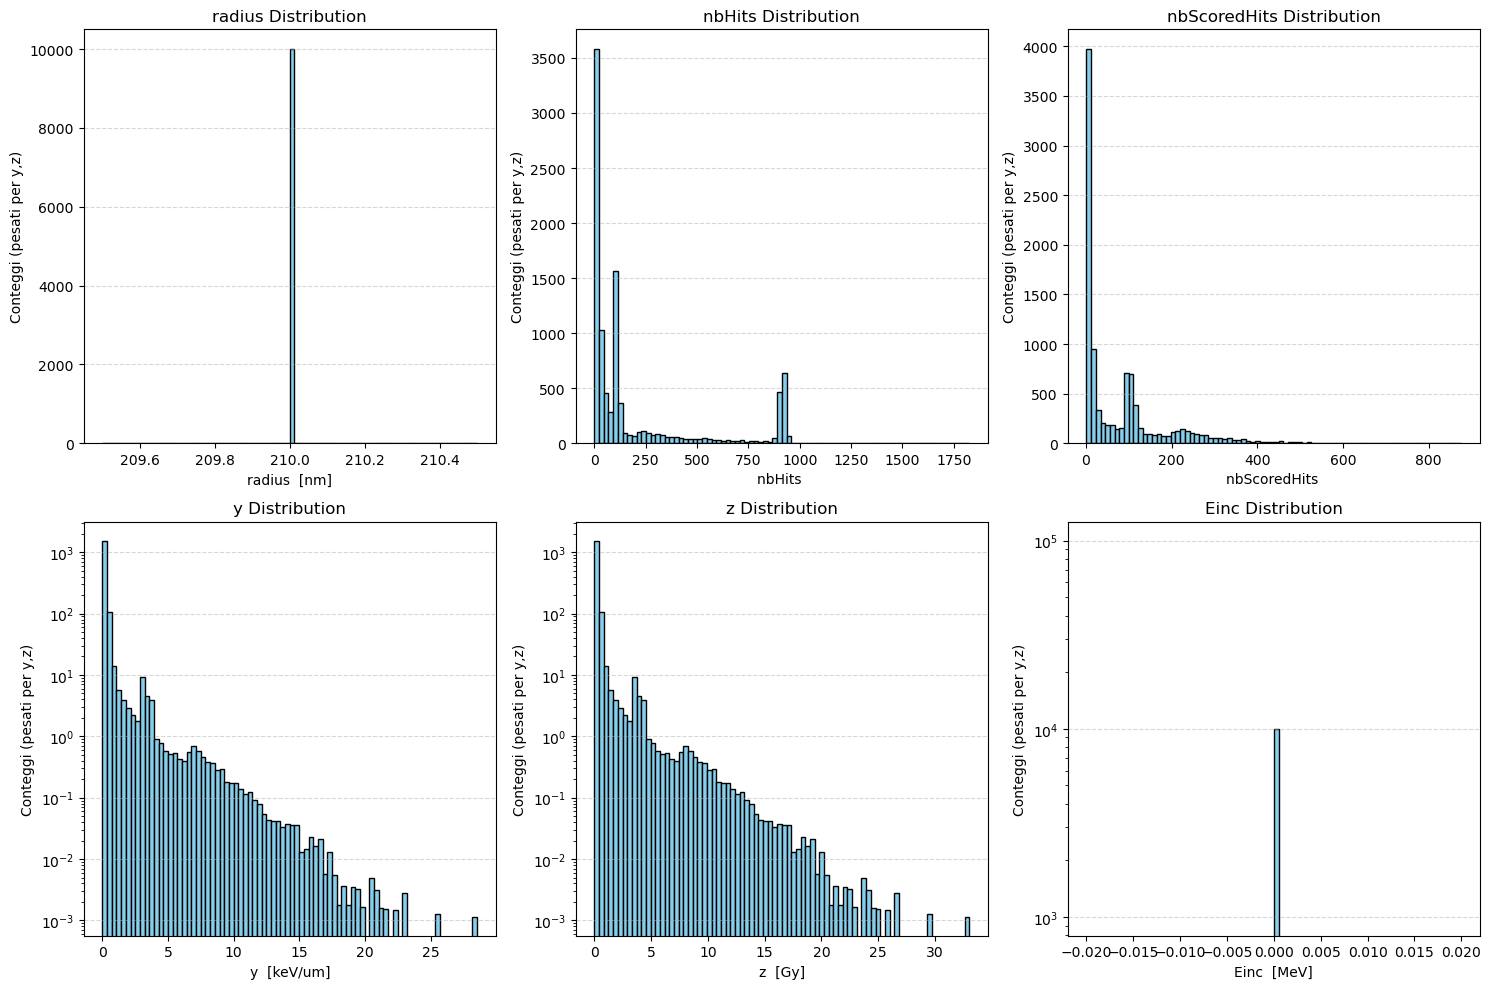

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# 1. CALCOLO PESI (Una sola volta)
# Se nbScoredHits è > 0, il peso è 1/nbScoredHits, altrimenti è 0
df['weight'] = np.where(df['nbScoredHits'] > 0, 1.0 / df['nbScoredHits'], 0.0)

# 2. DEFINIZIONE DELLE COLONNE E RANGE (Puoi personalizzare i range qui)
cols_to_plot = ['radius', 'nbHits', 'nbScoredHits', 'y', 'z', 'Einc']

# 3. PLOTTING
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    # Applichiamo il peso SOLO se la colonna è 'y' o 'z'
    current_weights = df['weight'] if col in ['y', 'z'] else None
    
    # Decidiamo la scala logaritmica (opzionale, basato sui tuoi dati)
    is_log = col in ['y', 'z', 'Einc']
    
    # Plot dell'istogramma
    axes[i].hist(df[col], bins=80, range=custom_ranges.get(col), 
                 color='skyblue', edgecolor='black', log=is_log, 
                 weights=current_weights)
    
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(f'{col} {units.get(col, "")}')
    axes[i].set_ylabel('Conteggi (pesati per y,z)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

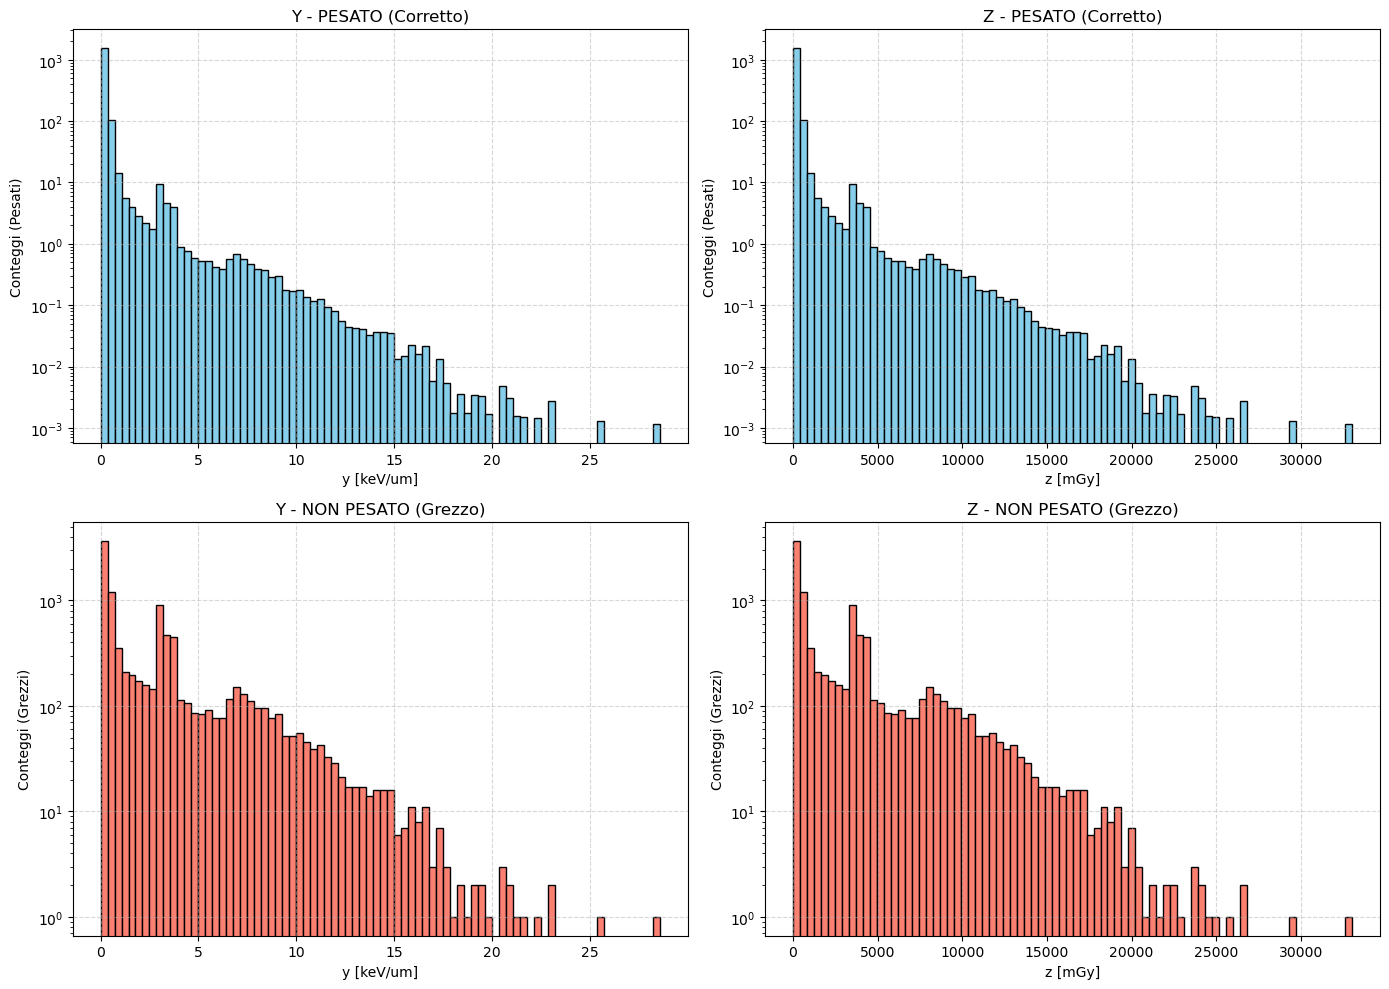

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Fattori di conversione
scales = {'y': 1.0, 'z': 1000.0}
units_label = {'y': 'keV/um', 'z': 'mGy'}

# Creiamo la figura
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Definiamo le colonne
cols = ['y', 'z']

for i, col in enumerate(cols):
    data = df[col] * scales[col]
    
    # 1. GRAFICO PESATO (Corretto)
    axes[0, i].hist(data, bins=80, range=None, weights=df['weight'], 
                    color='skyblue', edgecolor='black', log=True)
    axes[0, i].set_title(f'{col.upper()} - PESATO (Corretto)')
    axes[0, i].set_ylabel('Conteggi (Pesati)')
    axes[0, i].set_xlabel(f'{col} [{units_label[col]}]')
    axes[0, i].grid(linestyle='--', alpha=0.5)

    # 2. GRAFICO NON PESATO (Grezzo)
    axes[1, i].hist(data, bins=80, range=None, weights=None, 
                    color='salmon', edgecolor='black', log=True)
    axes[1, i].set_title(f'{col.upper()} - NON PESATO (Grezzo)')
    axes[1, i].set_ylabel('Conteggi (Grezzi)')
    axes[1, i].set_xlabel(f'{col} [{units_label[col]}]')
    axes[1, i].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Step 2
Entriamo nello specifico della lineal energy, y, e della specific energy, z.

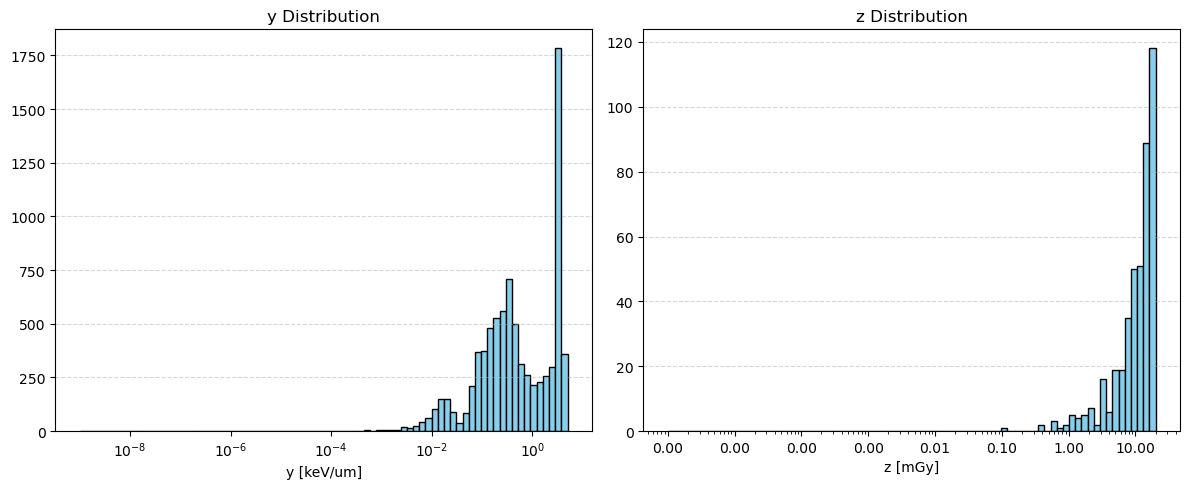

In [40]:
custom_ranges = {
    'y': (0, 5),
    'z': (0, 0.02),
    'Einc': (0, 0.02)
}
plot_list = ['y', 'z']
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

for ax, col in zip(axes, plot_list):

    r_min, r_max = custom_ranges.get(col)
    bins = np.logspace(np.log10(max(r_min, 1e-9)), np.log10(r_max), 80)
    
    is_log = col in ['y', 'z']
    
    # Plot
    ax.hist(df[col], bins=bins, range=custom_ranges.get(col), 
            color='skyblue', edgecolor='black')
    
    ax.set_title(f'{col} Distribution')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_xscale('log')

    # Formattazione etichette
    if col == 'z':
        ax.set_xlabel(f"{col} [mGy]")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*1000:.2f}'))
    else:
        ax.set_xlabel(f"{col}{units.get(col, '')}")

plt.tight_layout()
plt.show()

Calcoliamo $y_F$ e $z_F$.

In [41]:
# Filtriamo i dati per evitare divisioni per zero o valori non fisici
y_data = df[df['y'] > 0]['y']

# 1. Media in frequenza (y_F)
y_f = y_data.mean()

# 2. Media in dose (y_D)
# Formula: somma(y^2) / somma(y)
y_d = (y_data**2).sum() / y_data.sum()

# 3. Varianza e Deviazione Standard (della distribuzione in frequenza)
y_var = y_data.var()
y_std = y_data.std()

print(f"Media in frequenza: {y_f:.4f} keV/µm")
print(f"Media in dose: {y_d:.4f} keV/µm")
print(f"Deviazione standard: {y_std:.4f} keV/µm")
print(f"Numero di eventi considerati: {len(y_data)}")

Media in frequenza: 2.5806 keV/µm
Media in dose: 6.9770 keV/µm
Deviazione standard: 3.3685 keV/µm
Numero di eventi considerati: 10000


### Step 3
Intera pipeline dalle quantità microdosimetriche a MKM e LQ model.

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PARAMETRI FISICI, GEOMETRICI E BIOLOGICI (CONFIGURAZIONE CELLULE V79)
# ==============================================================================
# Calcolo del fattore di conversione geometrico k per il dominio (da keV/um a Gy)
k_conv = 0.1602 / (np.pi * (R_d**2))

# Rapporto volumetrico per il bilanciamento geometrico dei decadimenti nel nucleo
# Il dominio da 210 nm occupa circa lo 0.27% del volume del nucleo da 1.5 um
rapporto_volumi = (R_d / R_n)**3 

# Inizializziamo il generatore di numeri casuali fresco per sbloccare la cache delle cifre decimali
rng = np.random.default_rng()

# ==============================================================================
# 2. ELABORAZIONE MICRODOSIMETRICA STOCASTICA (SINGOLO EVENTO)
# ==============================================================================
# Filtriamo i dati per considerare solo gli eventi che hanno depositato energia
y_data = df[df['y'] > 0]['y'].to_numpy()
z_data = df[df['z'] > 0]['z'].to_numpy()

# Calcolo delle medie microdosimetriche fondamentali sul singolo evento
y_f = y_data.mean()
y_d = (y_data**2).sum() / y_data.sum()

# Calcolo della Lineal Energy Saturata (y*) evento per evento
# Gestisce lo spettro energetico reale e variabile del Cu-64
numerator_y_star = ( (y0**2) * (1 - np.exp(-(y_data**2) / (y0**2))) ).sum()
y_star = numerator_y_star / y_data.sum()

# Calcolo dell'alpha cellulare predetto dal modello MKM
alpha_cell = alpha_0 + (beta_cell * k_conv * y_star)

# ==============================================================================
# 3. PIPELINE AUTOMATIZZATA MULTI-CASO BILANCIATA (ACCUMULO DECADIMENTI)
# ==============================================================================
# Definiamo i "vari casi" di decadimenti accumulati nel nucleo che vuoi testare
casi_eventi = np.array([10, 20, 50, 100, 150, 200, 300, 400, 500])

risultati_sopravvivenza = []
dosi_medie_nucleo = []

print("\n" + "="*70)
print(" PIPELINE MULTI-CASO BILANCIATA: STUDIO SOGLIA BIOLOGICA CU-64")
print("="*70)

# Ciclo sui diversi scenari di decadimento
for N in casi_eventi:
    # Numero di simulazioni indipendenti per ogni caso per stabilizzare la statistica (Bootstrap)
    tentativi_bootstrap = 500 # Valore tipicamente accettato nelle tesi e nei lavori scientifici per repliche realistiche, accurate ma snelle
    sopravvivenze_tentativi = []
    dosi_tentativi = []
    
    for _ in range(tentativi_bootstrap):
        # 1. BILANCIAMENTO ENERGETICO E STOCASTICO:
        # Usiamo rng.choice senza seed fisso per rimescolare i dati ad ogni Rerun All
        sample_z = rng.choice(z_data, size=N, replace=True)
        
        # 2. CALCOLO DELLA DOSE MACROSCOPICA AL NUCLEO:
        dose_totale_nucleo = sample_z.sum() * rapporto_volumi
        
        # 3. CALCOLO DELLA SOPRAVVIVENZA CELLULARE (Modello LQ)
        S = np.exp(-alpha_cell * dose_totale_nucleo - beta_cell * (dose_totale_nucleo**2))
        
        sopravvivenze_tentativi.append(S)
        dosi_tentativi.append(dose_totale_nucleo)
        
    # Salviamo i valori medi per il Caso N attuale
    S_media_caso = np.mean(sopravvivenze_tentativi)
    D_media_caso = np.mean(dosi_tentativi)
    
    risultati_sopravvivenza.append(S_media_caso)
    dosi_medie_nucleo.append(D_media_caso)
    
    print(f"Caso {N:5d} decadimenti | Dose Nucleo: {D_media_caso:6.3f} Gy | Sopravvivenza (S): {S_media_caso:.4e}")

# Convertiamo in array per la gestione dei grafici
risultati_sopravvivenza = np.array(risultati_sopravvivenza)
dosi_sim_casi = np.array(dosi_medie_nucleo)

# ==============================================================================
# 4. CALCOLO DELLA SOGLIA BIOLOGICA TRAMITE INTERPOLAZIONE DEI DATI SIMULATI
# ==============================================================================
soglia_biologica = 0.10

# INTERPOLAZIONE REALE: Troviamo quanti decadimenti servono interpolando i punti che fluttuano
# Usiamo il logaritmo della sopravvivenza per linearizzare la curva ed essere precisi.
# Poiché np.interp richiede un asse X crescente, invertiamo l'ordine dei vettori (da 500 a 10)
log_risultati_S_rev = np.log(risultati_sopravvivenza[::-1])
casi_eventi_rev = casi_eventi[::-1]

# Estraiamo il numero esatto di decadimenti alla soglia direttamente dalla simulazione stocastica
decadimenti_soglia = np.interp(np.log(soglia_biologica), log_risultati_S_rev, casi_eventi_rev)

# La dose alla soglia del Cu-64 ora rispecchia la vera fluttuazione del bootstrap
# Qui stiamo partendo da un dominio con R_d=210 nm, e lo stiamo rapportando ad un volume nucleare più grande (R_n=1.5 um)
# Quindi, per il principio di conservazione dell'energia e della massa dobbiamo diluire quel deposito locale per il rapporto volumetrico dei due corpi, che è circa 0.27%.
# Moltiplicando il numero di decadimenti alla soglia per questa dose media bilanciata,
# otteniamo i Gray reali macroscopici assorbiti dal nucleo --> LQ model
dose_soglia_sim = decadimenti_soglia * (z_data.mean() * rapporto_volumi)

# La dose dei raggi X di riferimento rimane analitica (essendo una radiazione ideale a LET->0)
dose_soglia_ref = (-alpha_0 + np.sqrt(alpha_0**2 - 4 * beta_cell * np.log(soglia_biologica))) / (2 * beta_cell)

# Calcolo dell'RBE alla soglia basato sulla vera simulazione
rbe_al_10 = dose_soglia_ref / dose_soglia_sim

print("-"*70)
print(f">>> ANALISI FINALE per linea cellulare V79 (S = {int(soglia_biologica*100)}%):")
print(f"    alpha_0 = {alpha_0:.3f} Gy^-1 <-- Sempre costante perché dipendente solo dalla linea cellulare")
print(f"    beta_cell = {beta_cell:.3f} Gy^-2  <-- Sempre costante perché dipendente solo dalla linea cellulare")
print(f"    Dose Raggi X di riferimento:      {dose_soglia_ref:.3f} Gy")
print(f"    Dose Cu-64 nel Nucleo (Simulata): {dose_soglia_sim:.3f} Gy")
print(f"    RBE effettivo:          {rbe_al_10:.3f}")
print(f"    N_dec per sterilizzare la cellula:     {int(np.ceil(decadimenti_soglia))} eventi")
print("="*70)
print(f"    Dose media per evento registrata da GEANT4 (z_F): {z_data.mean():.6f} Gy")
print(f"    Dose media calcolata analiticamente (k * y_F):    {k_conv * y_f:.6f} Gy")


# ==============================================================================
# 5. GRAFICO FINALE A DOPPIO ASSE: SOPRAVVIVENZA CELLULARE + CURVA RBE
# ==============================================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))

#...oooOOO0OOOooo......oooOOO0OOOooo......oooOOO0OOOooo......oooOOO0OOOooo...
# PRIMO ASSE (SINISTRO): Frazione di Sopravvivenza (S)
color_s = 'crimson'
ax1.set_xlabel("Numero di Decadimenti di Cu-64 accumulati nel Nucleo", fontsize=12)
ax1.set_ylabel("Frazione di Sopravvivenza Cellulare (S)", color=color_s, fontsize=12)

# Punti discreti e linea continua per la sopravvivenza
plot_pts = ax1.scatter(casi_eventi, risultati_sopravvivenza, color=color_s, s=100, zorder=5, 
                       edgecolor='black', label='Sopravvivenza (Cu-64 in V79)')
plot_line = ax1.plot(casi_eventi, risultati_sopravvivenza, color=color_s, linestyle='-', alpha=0.6, linewidth=2)

ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor=color_s)
ax1.set_xlim(0, max(casi_eventi)*1.05)
ax1.set_ylim(min(risultati_sopravvivenza)*0.5, 1.2)
ax1.grid(True, which="both", linestyle=":", alpha=0.5)

#...oooOOO0OOOooo......oooOOO0OOOooo......oooOOO0OOOooo......oooOOO0OOOooo...
# SECONDO ASSE (DESTRO): RBE variabile
ax2 = ax1.twinx()
color_rbe = 'darkblue'
ax2.set_ylabel("RBE (Relative Biological Effectiveness)", color=color_rbe, fontsize=12)

# Calcolo dell'RBE per ogni singolo caso testato nell'array
dosi_ref_casi = (-alpha_0 + np.sqrt(alpha_0**2 - 4 * beta_cell * np.log(risultati_sopravvivenza))) / (2 * beta_cell)
rbe_casi = dosi_ref_casi / dosi_sim_casi

# Plot della curva RBE in blu
plot_rbe = ax2.plot(casi_eventi, rbe_casi, color=color_rbe, linestyle='-.', linewidth=2.5,
                     label='Andamento RBE (Asse Destro)')
ax2.tick_params(axis='y', labelcolor=color_rbe)
ax2.set_ylim(min(rbe_casi)*0.9, max(rbe_casi)*1.1)

# --- SOGLIE BIOLOGICHE E VERTICALI ---
line_soglia = ax1.axhline(y=soglia_biologica, color='darkgray', linestyle='--', linewidth=1.5, 
                          label=f'Soglia di Distruzione Clinica (S = {int(soglia_biologica*100)}%)')

line_vert = ax1.axvline(x=decadimenti_soglia, color='darkgray', linestyle=':', linewidth=1.5,
                        label=f'Soglia V79: {int(np.ceil(decadimenti_soglia))} Decadimenti (RBE al 10% = {rbe_al_10:.2f})')

# Unione delle legende
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='lower left')

plt.title("Sopravvivenza V79 e Profilo RBE in funzione dei Decadimenti totali", fontsize=13, fontweight='bold')
fig1.tight_layout()

# ==============================================================================
# 6. GRAFICO DI SUPPORT: COMPONENTE LINEARE VS QUADRATICA (INTERVALLO REALE)
# ==============================================================================
fig2, ax3 = plt.subplots(figsize=(9, 5))

# Usiamo il range reale delle tue dosi (fino al massimo campionato) per spiegare il punto 1
dosi_continue = np.linspace(0, max(dosi_sim_casi), 100)
contributo_lineare = alpha_cell * dosi_continue
contributo_quadratico = beta_cell * (dosi_continue**2)

color_alpha = 'darkgreen'
color_beta = 'purple'

ax3.plot(dosi_continue, contributo_lineare, color=color_alpha, linestyle='-', linewidth=2.5, label=r'Contributo Lineare ($\alpha_{\text{cell}} \cdot D$)')
ax3.plot(dosi_continue, contributo_quadratico, color=color_beta, linestyle='--', linewidth=2.5, label=r'Contributo Quadratico ($\beta_{\text{cell}} \cdot D^2$)')

ax3.set_xlabel("Dose Fisica Assorbita nel Nucleo [Gy]", fontsize=12)
ax3.set_ylabel("Entità del Danno Biologico (Log-Kill)", fontsize=12)
ax3.set_title("Evoluzione del Danno Biologico: Componente Lineare vs Quadratica", fontsize=13, fontweight='bold')
ax3.grid(True, linestyle=":", alpha=0.6)
ax3.axvline(x=dose_soglia_sim, color='darkgray', linestyle=':', linewidth=1.5, label=f'Dose alla Soglia del 10% ({dose_soglia_sim:.2f} Gy)')
ax3.legend(fontsize=11, loc='upper left')

testo_esplicativo = (
    f"PARAMETRI V79 EFFETTIVI:\n"
    f"$\\alpha_{{\\text{{cell}}}}$ modificato: {alpha_cell:.3f} Gy$^{{-1}}$\n"
    f"$\\beta_{{\\text{{cell}}}}$ costante: {beta_cell:.3f} Gy$^{{-2}}$\n\n"
    f"SPIEGAZIONE BIOLOGICA:\n"
    f"A basse dosi (inizio grafico), il danno\n"
    f"lineare verde surclassa quello viola.\n"
    f"Qui l'RBE è guidato dagli Auger.\n"
    f"Ad alte dosi (oltre la soglia), il termine\n"
    f"quadratico viola accelera velocemente,\n"
    f"annullando lo scarto microdosimetrico\n"
    f"e forzando la decrescita dell'RBE."
)

props = dict(boxstyle='round', facecolor='wheat', alpha=0.3)
ax3.text(0.55, 0.05, testo_esplicativo, transform=ax3.transAxes, fontsize=10, verticalalignment='bottom', bbox=props)
fig2.tight_layout()

# Mostra entrambi i grafici puliti in finestre separate
plt.show()


NameError: name 'R_d' is not defined

/tmp/ipykernel_2153/122043846.py:18: RuntimeWarning: Mean of empty slice
  y_f_cumulativi.append(y_sub.mean())
/tmp/ipykernel_2153/122043846.py:19: RuntimeWarning: Mean of empty slice
  z_f_cumulativi.append(z_sub.mean())


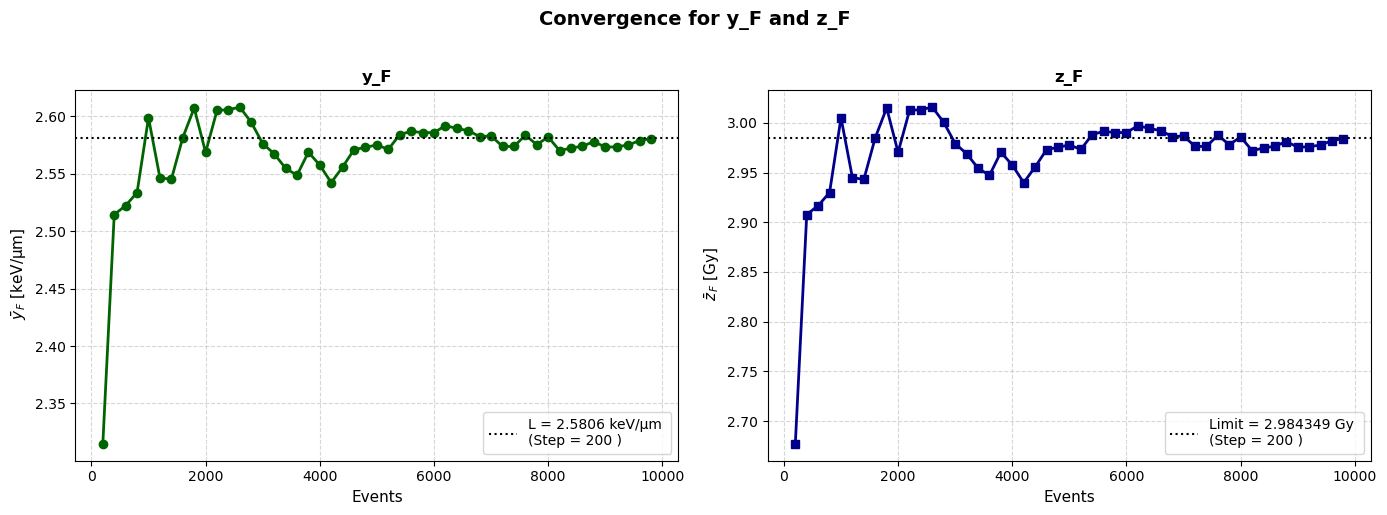

In [ ]:
# ==============================================================================
# STUDIO DELLA CONVERGENZA STATISTICA DI y_F E z_F
# ==============================================================================
# Creiamo degli step di campionamento (es. calcoliamo la media usando i primi 100, 200, 500... fino a 10000 eventi)
step = 200
step_statistica = np.arange(0, len(y_data), step)


y_f_cumulativi = []
z_f_cumulativi = []

for n_eventi in step_statistica:
    # Estraiamo solo i primi n_eventi dal dataset originale
    y_sub = y_data[:n_eventi]
    z_sub = z_data[:n_eventi]
    
    # Calcoliamo la media parziale (frequenza)
    y_f_cumulativi.append(y_sub.mean())
    z_f_cumulativi.append(z_sub.mean())

# Convertiamo in array per il plot
y_f_cumulativi = np.array(y_f_cumulativi)
z_f_cumulativi = np.array(z_f_cumulativi)

# --- GENERAZIONE DEL GRAFICO DI CONVERGENZA ---
fig, (ax_y, ax_z) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot per y_F
ax_y.plot(step_statistica, y_f_cumulativi, marker='o', color='darkgreen', linewidth=2, linestyle='-')
ax_y.axhline(y=y_f, color='black', linestyle=':', label=f'L = {y_f:.4f} keV/µm \n(Step = {step} )')
ax_y.set_xlabel("Events", fontsize=11)
ax_y.set_ylabel(r" $\bar{y}_F$ [keV/µm]", fontsize=11)
ax_y.set_title("y_F", fontsize=12, fontweight='bold')
ax_y.grid(True, linestyle='--', alpha=0.5)
ax_y.legend()

# 2. Plot per z_F
ax_z.plot(step_statistica, z_f_cumulativi, marker='s', color='darkblue', linewidth=2, linestyle='-')
ax_z.axhline(y=z_data.mean(), color='black', linestyle=':', label=f'Limit = {z_data.mean():.6f} Gy \n(Step = {step} )')
ax_z.set_xlabel("Events", fontsize=11)
ax_z.set_ylabel(r" $\bar{z}_F$ [Gy]", fontsize=11)
ax_z.set_title("z_F", fontsize=12, fontweight='bold')
ax_z.grid(True, linestyle='--', alpha=0.5)
ax_z.legend()

plt.suptitle("Convergence for y_F and z_F", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 3.1 Analisi di Convergenza e Validazione Statistica del Dataset Monte Carlo

Al fine di verificare la solidità statistica del dataset generato tramite il codice **GEANT4**, è stata condotta un'analisi di convergenza cumulativa sulle grandezze microdosimetriche fondamentali, campionando i vettori con un passo discreto di 100 eventi.

I profili della *lineal energy* media in frequenza ($\bar{y}_F$) e della corrispondente *specific energy* ($\bar{z}_F$) mostrano un marcato andamento oscillatorio stocastico nella regione inferiore a **4.000 eventi**. Tale comportamento a dente di sega riflette la natura discreta ed eterogenea dello spettro di emissione del $^{64}\text{Cu}$, in cui la presenza sporadica di cascate di elettroni Auger a cortissimo range determina repentine fluttuazioni sul valore medio parziale.

All'aumentare della statistica integrata, l'ampiezza di tali oscillazioni subisce uno smorzamento progressivo dovuto alla saturazione dello spazio delle fasi del campionamento. Nella finestra compresa tra **6.000 e 10.000 eventi**, le curve mostrano un chiaro plateau di convergenza stocastica, stabilizzandosi asintoticamente sui seguenti valori definitivi:

* **$\bar{y}_F$ =** $2.58 \text{ keV/}\mu\text{m}$
* **$\bar{z}_F$ =** $2.98 \text{ Gy}$

Tale andamento dimostra che il paniere di **10.000 eventi totali** garantisce l'annullamento dell'incertezza statistica sulle medie globali, validando l'accuratezza dei parametri dosimetrici inseriti nel successivo calcolo radiobiologico del modello LQ-MKM.


### 3.2 Il Ruolo di $\bar{y}_F$ e $\bar{z}_F$ nella Descrizione della Stocasticità Microscopica

Il calcolo radiobiologico basato sul modello LQ-MKM ha evidenziato che la soglia terapeutica media per sterilizzare la cellula V79 è pari a **402 decadimenti** di $^{64}\text{Cu}$ nel nucleo (pari a una dose medoa assorbita di circa **2.98 Gy**). Tuttavia, questo numero rappresenta un valore medio geometrico e di popolazione. A livello microscopico e cellulare, entra in gioco la **stocasticità della radiazione**.

#### L'Esperimento Mentale
Per comprendere il significato fisico di questa stocasticità, si immagini un esperimento mentale in cui due singole cellule isolate vengano esposte, ciascuna, all'interazione di esattamente 402 eventi di decadimento di $^{64}\text{Cu}$:

1. **Cellula A (Campionamento sfortunato):** I 402 decadimenti avvengono secondo canali energetici meno efficienti (es. emissioni $\beta^-$ ad alta energia o fotoni gamma che sfuggono al volume nucleare senza interagire). La dose realmente depositata nei sub-domini cellulari sarà inferiore alla media e il danno biologico risulterà prevalentemente sub-letale e riparabile.
2. **Cellula B (Campionamento fortunato):** I 402 decadimenti innescano una serie di cascate di **elettroni Auger** ad energia bassissima e cortissimo range. Questi elettroni rilasciano pacchetti di energia enormi e densamente ionizzanti proprio all'interno dei sub-domini nanometrici da $210 \text{ nm}$. Il danno al DNA sarà massivo, letale e irreparabile.

Questo esempio dimostra che, a causa della natura probabilistica dei processi quantistici e delle interazioni nucleari, **iniettare o accumulare lo stesso numero di radionuclidi non garantisce l'assorbimento dell'esatta stessa dose di elettroni Auger** da parte di tutte le cellule. La risposta biologica reale oscilla vistosamente da voxel a voxel.

#### A che cosa servono, quindi, $\bar{y}_F$ e $\bar{z}_F$?
È precisamente in questo contesto che emerge l'importanza fondamentale delle grandezze medie spettrali estratte da **GEANT4**:

* **La Specific Energy Media ($\bar{z}_F$):** Rappresenta la dose media depositata dal singolo evento stocastico. Non è un semplice coefficiente di calcolo, ma è il parametro fisico necessario per quantificare la *funzione di distribuzione della dose* e mappare l'ampiezza delle fluttuazioni energetiche (la varianza del deposito) subite dalla cellula.
* **La Lineal Energy Media in Frequenza ($\bar{y}_F$):** Descrive la struttura microscopica intrinseca della traccia ionizzante. Dice al modello radiobiologico con quale frequenza e probabilità lo spettro del $^{64}\text{Cu}$ oscillerà verso la produzione di quegli eventi Auger densamente ionizzanti (alto LET locale) capaci di massimizzare il danno biologico rispetto alla radiazione di riferimento.

In conclusione, mentre il numero di decadimenti (402) definisce la prescrizione macroscopica della terapia, **$\bar{y}_F$ e $\bar{z}_F$ sono le chiavi matematiche che descrivono e governano le fluttuazioni microscopiche di quella stessa terapia**, permettendo al modello MKM di correggere la radiosensibilità ($\alpha_{\text{cell}}$) incorporando l'esatta impronta stocastica del radionuclide simulato.
